<a href="https://colab.research.google.com/github/23424028/Matkul-pengolahan-citra-digital/blob/main/Tugas_PCD_pertemuan3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

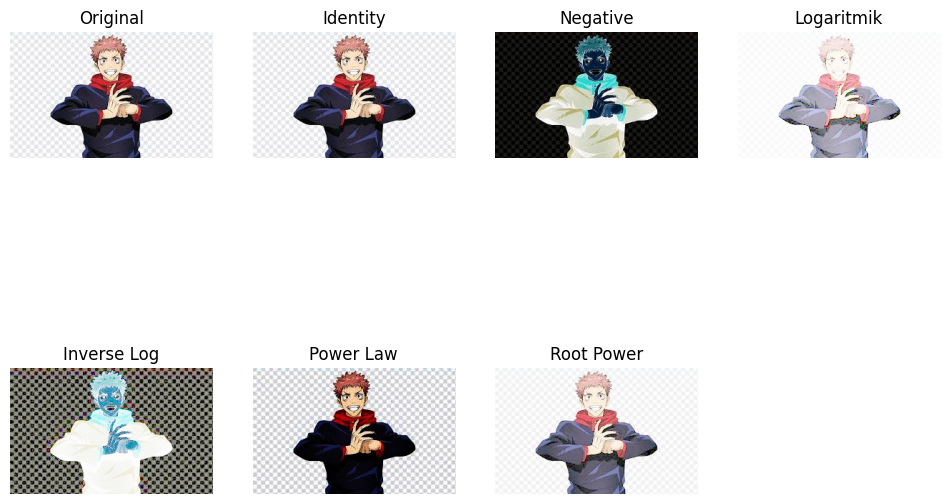

In [1]:

import cv2
import numpy as np
import matplotlib.pyplot as plt

# ===============================
# Membaca gambar
# ===============================
img = cv2.imread("yuji.jpeg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# ubah ke float agar perhitungan stabil
img_float = img.astype(np.float32)

L = 255

# ===============================
# 1 Identity
# ===============================
identity = img.copy()

# ===============================
# 2 Negative
# G = L - F
# ===============================
negative = L - img

# ===============================
# 3 Log Transform
# G = c log(F+1)
# ===============================
c = 255 / np.log(1 + np.max(img_float))
log_transform = c * np.log(img_float + 1)
log_transform = np.uint8(log_transform)

# ===============================
# 4 Inverse Log
# G = c log(L-F+1)
# ===============================
inverse_log = c * np.log(L - img_float + 1)
inverse_log = np.uint8(inverse_log)

# ===============================
# 5 Power Law (nth power)
# G = cF^y
# ===============================
gamma = 2
power_law = np.array(255 * (img_float / 255) ** gamma, dtype='uint8')

# ===============================
# 6 Root Power (nth root)
# G = cF^(1/y)
# ===============================
gamma = 2
root_power = np.array(255 * (img_float / 255) ** (1/gamma), dtype='uint8')

# ===============================
# Menampilkan hasil
# ===============================
titles = [
    "Original",
    "Identity",
    "Negative",
    "Logaritmik",
    "Inverse Log",
    "Power Law",
    "Root Power"
]

images = [
    img,
    identity,
    negative,
    log_transform,
    inverse_log,
    power_law,
    root_power
]

plt.figure(figsize=(12,8))

for i in range(len(images)):
    plt.subplot(2,4,i+1)
    plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis("off")

plt.show()